## Libraries

In [1]:
import numpy as np
import pandas as pd
import inspect
import math
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Rectangle
import seaborn as sns
from os.path import commonprefix
import tabulate

/opt/anaconda3/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


## Pedigree scores

In [2]:
#source : https://link.springer.com/article/10.1007/s11367-013-0670-5/tables/6
pedigree = {
    "reliability": (1.0, 1.54, 1.61, 1.69, 1.69),
    "completeness": (1.0, 1.03, 1.04, 1.08, 1.08),
    "temporal correlation": (1.0, 1.03, 1.1, 1.19, 1.29),
    "geographical correlation": (1.0, 1.04, 1.08, 1.11, 1.11),
    "further technological correlation": (1.0, 1.18, 1.65, 2.08, 2.8),
    "sample size": (1.0, 1.0, 1.0, 1.0, 1.0),
}

## Functions

In [3]:
#Pedigree matrix to lognormal
def pedigree_to_sigma(rel, com, tem, geo, tec):
    return math.exp(math.sqrt(pow(math.log(pedigree['reliability'][rel-1]),2)+pow(math.log(pedigree['completeness'][com-1]),2)+pow(math.log(pedigree['temporal correlation'][tem-1]),2)+pow(math.log(pedigree['geographical correlation'][geo-1]),2)+pow(math.log(pedigree['further technological correlation'][tec-1]),2)))

#First order Sobol' indices
def SI_1st(x,y,iterations,brackets):
    bracket_size = int(iterations/brackets)
    pairs = np.column_stack(((y,x)))
    pairs = pairs[pairs[:, 1].argsort()]
    GSA = pairs[:,0]
    GSA = np.reshape(GSA,(brackets,bracket_size))
    bracket_means=np.mean(GSA, axis=1)
    return(np.var(bracket_means)/np.var(y))

## Initialization

In [4]:
iterations = 1000
np.random.seed(1)

In [5]:
#background uncertainty
background = pd.read_excel("input.xlsx", sheet_name="background", index_col=0, header=None)

time_impact_elec = background.loc['t_impact_elec'][1]
impact_elec = background.loc['t_impact_elec'][2]
t_impact_elec = background.loc['t_impact_elec'][2:].to_numpy()
#t_impact_elec = np.array([impact_elec]*1000)
time_impact_arg = background.loc['t_impact_arg'][1]
impact_arg = background.loc['t_impact_arg'][2]
t_impact_arg = background.loc['t_impact_arg'][2:].to_numpy()
#t_impact_arg = np.array([impact_arg]*1000)
time_impact_draw = background.loc['t_impact_draw'][1]
impact_draw = background.loc['t_impact_draw'][2]
t_impact_draw = background.loc['t_impact_draw'][2:].to_numpy()
#t_impact_draw = np.array([impact_draw]*1000)
time_impact_roll = background.loc['t_impact_roll'][1]
impact_roll = background.loc['t_impact_roll'][2]
t_impact_roll = background.loc['t_impact_roll'][2:].to_numpy()
#t_impact_roll = np.array([impact_roll]*1000)
time_impact_cast = background.loc['t_impact_cast'][1]
impact_cast = background.loc['t_impact_cast'][2]
t_impact_cast = background.loc['t_impact_cast'][2:].to_numpy()
#t_impact_cast =np.array([impact_cast]*1000)
time_impact_steel = background.loc['t_impact_steel'][1]
impact_steel = background.loc['t_impact_steel'][2]
t_impact_steel = background.loc['t_impact_steel'][2:].to_numpy()
#t_impact_steel = np.array([impact_steel]*1000)
time_impact_nit = background.loc['t_impact_nit'][1]
impact_nit = background.loc['t_impact_nit'][2]
t_impact_nit = background.loc['t_impact_nit'][2:].to_numpy()
#t_impact_nit = np.array([impact_nit]*1000)
time_impact_heat = background.loc['t_impact_heat'][1]
impact_heat = background.loc['t_impact_heat'][2]
t_impact_heat = background.loc['t_impact_heat'][2:].to_numpy()
#t_impact_heat = np.array([impact_heat]*1000)

## Background GSA

/opt/anaconda3/lib/python3.7/site-packages/matplotlib/colors.py:235: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  c = np.array(c)


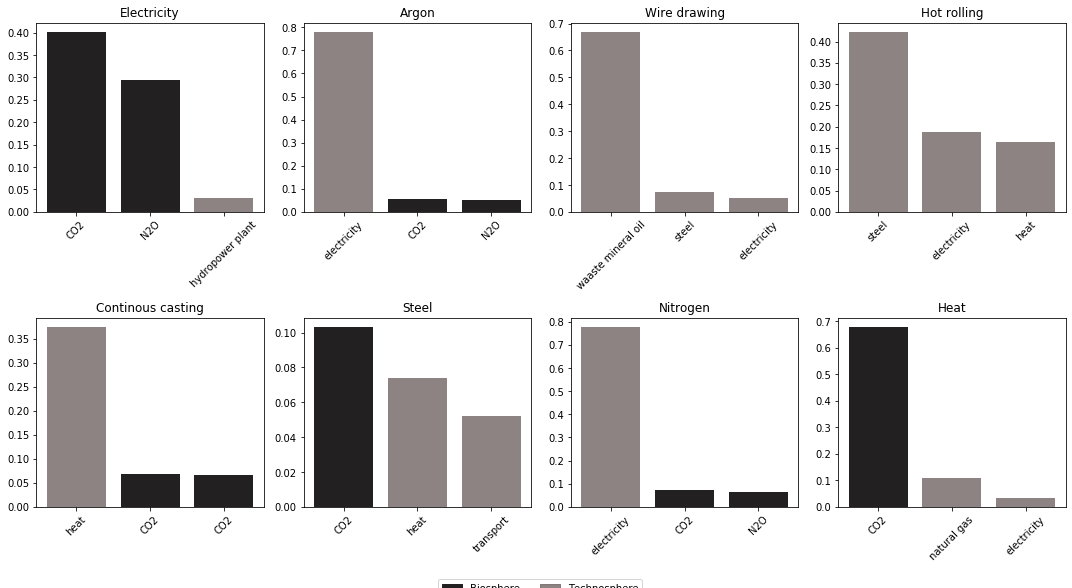

In [6]:
gsa_background = pd.read_excel("input.xlsx", sheet_name="GSA", header=None)
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(15, 8))
color_map = {'biosphere': (34/255, 32/255, 33/255), 'technosphere': (100/225, 100/255, 100/255, 0.8)}

for i in range(8):
    start = i * 4 + 1
    end = (i + 1) * 4
    
    title = gsa_background.iloc[start, 1]
    data = gsa_background.iloc[start + 1:end + 1, 1:4]
    axs[int(i/4),i%4].set_title(title)
    axs[int(i/4),i%4].set_xticks(range(3))
    axs[int(i/4),i%4].set_xticklabels(list(data[1]), rotation=45)
    axs[int(i/4),i%4].bar(range(3), list(data[2]), align='center', 
        color=[color_map[data.loc[(4*i)+2,3]],color_map[data.loc[(4*i)+3,3]],color_map[data.loc[(4*i)+4,3]]])
legend_elements = [
    Rectangle((0, 0), 1, 1, color=color_map['biosphere'], label='Biosphere'),
    Rectangle((0, 0), 1, 1, color=color_map['technosphere'], label='Technosphere')]
    
fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, 0), ncol=2)  # Adjust ncol as needed
plt.tight_layout()
plt.savefig("Figure S4.jpg", format="jpg", dpi=400, bbox_inches='tight')
plt.show()

In [7]:
#background applicability uncertainty
applicability = pd.read_excel("input.xlsx", sheet_name="applicability", index_col=0, header=None)

time_a_elec = applicability.loc['a_elec'][1]
a_elec = applicability.loc['a_elec'][2].split(',')
a_elec_log = stats.norm.rvs(loc=math.log(1),scale=math.log(pedigree_to_sigma(int(a_elec[0]),int(a_elec[1]),int(a_elec[2]),int(a_elec[3]),int(a_elec[4])))/2, size=iterations)
a_elec = np.exp(a_elec_log)
time_a_arg = applicability.loc['a_arg'][1]
a_arg = applicability.loc['a_arg'][2].split(',')
a_arg_log = stats.norm.rvs(loc=math.log(1),scale=math.log(pedigree_to_sigma(int(a_arg[0]),int(a_arg[1]),int(a_arg[2]),int(a_arg[3]),int(a_arg[4])))/2, size=iterations)
a_arg = np.exp(a_arg_log)
time_a_draw = applicability.loc['a_draw'][1]
a_draw = applicability.loc['a_draw'][2].split(',')
a_draw_log = stats.norm.rvs(loc=math.log(1),scale=math.log(pedigree_to_sigma(int(a_draw[0]),int(a_draw[1]),int(a_draw[2]),int(a_draw[3]),int(a_draw[4])))/2, size=iterations)
a_draw = np.exp(a_draw_log)
time_a_roll = applicability.loc['a_roll'][1]
a_roll = applicability.loc['a_roll'][2].split(',')
a_roll_log = stats.norm.rvs(loc=math.log(1),scale=math.log(pedigree_to_sigma(int(a_roll[0]),int(a_roll[1]),int(a_roll[2]),int(a_roll[3]),int(a_roll[4])))/2, size=iterations)
a_roll = np.exp(a_roll_log)
time_a_cast = applicability.loc['a_cast'][1]
a_cast = applicability.loc['a_cast'][2].split(',')
a_cast_log = stats.norm.rvs(loc=math.log(1),scale=math.log(pedigree_to_sigma(int(a_cast[0]),int(a_cast[1]),int(a_cast[2]),int(a_cast[3]),int(a_cast[4])))/2, size=iterations)
a_cast = np.exp(a_cast_log)
time_a_steel = applicability.loc['a_steel'][1]
a_steel = applicability.loc['a_steel'][2].split(',')
a_steel_log = stats.norm.rvs(loc=math.log(1),scale=math.log(pedigree_to_sigma(int(a_steel[0]),int(a_steel[1]),int(a_steel[2]),int(a_steel[3]),int(a_steel[4])))/2, size=iterations)
a_steel = np.exp(a_steel_log)
time_a_nit = applicability.loc['a_nit'][1]
a_nit = applicability.loc['a_nit'][2].split(',')
a_nit_log = stats.norm.rvs(loc=math.log(1),scale=math.log(pedigree_to_sigma(int(a_nit[0]),int(a_nit[1]),int(a_nit[2]),int(a_nit[3]),int(a_nit[4])))/2, size=iterations)
a_nit = np.exp(a_nit_log)
time_a_heat = applicability.loc['a_heat'][1]
a_heat = applicability.loc['a_heat'][2].split(',')
a_heat_log = stats.norm.rvs(loc=math.log(1),scale=math.log(pedigree_to_sigma(int(a_heat[0]),int(a_heat[1]),int(a_heat[2]),int(a_heat[3]),int(a_heat[4])))/2, size=iterations)
a_heat = np.exp(a_heat_log)

In [8]:
#foreground uncertainty | mostly p
foreground = pd.read_excel("input.xlsx", sheet_name="parameters", index_col=0, header=None)

time_wire_fr = foreground.loc['p_wire_fr'][1]
wire_fr = foreground.loc['p_wire_fr'][2]
p_wire_fr = foreground.loc['p_wire_fr'][3].split(',')
p_wire_fr = np.random.uniform (float(p_wire_fr[0]),float(p_wire_fr[1]),iterations)
time_shi_gas_fr = foreground.loc['p_shi_gas_fr'][1]
shi_gas_fr = foreground.loc['p_shi_gas_fr'][2]
p_shi_gas_fr = foreground.loc['p_shi_gas_fr'][3].split(',')
p_shi_gas_fr = np.random.uniform (float(p_shi_gas_fr[0]),float(p_shi_gas_fr[1]),iterations)
time_power_wa = foreground.loc['p_power_wa'][1]
power_wa = foreground.loc['p_power_wa'][2]
p_power_wa = foreground.loc['p_power_wa'][3].split(',')
p_power_wa = np.random.uniform (float(p_power_wa[0]),float(p_power_wa[1]),iterations)
time_dep_eff_wa = foreground.loc['p_dep_eff_wa'][1]
dep_eff_wa = foreground.loc['p_dep_eff_wa'][2]
p_dep_eff_wa = foreground.loc['p_dep_eff_wa'][3].split(',')
p_dep_eff_wa = np.random.uniform (float(p_dep_eff_wa[0]),float(p_dep_eff_wa[1]),iterations)
time_powder_fr = foreground.loc['p_powder_fr'][1]
powder_fr = foreground.loc['p_powder_fr'][2]
p_powder_fr = foreground.loc['p_powder_fr'][3].split(',')
p_powder_fr = np.random.uniform (float(p_powder_fr[0]),float(p_powder_fr[1]),iterations)
time_car_gas_fr = foreground.loc['p_car_gas_fr'][1]
car_gas_fr = foreground.loc['p_car_gas_fr'][2]
p_car_gas_fr = foreground.loc['p_car_gas_fr'][3].split(',')
p_car_gas_fr = np.random.uniform (float(p_car_gas_fr[0]),float(p_car_gas_fr[1]),iterations)
time_power_cs = foreground.loc['p_power_cs'][1]
power_cs = foreground.loc['p_power_cs'][2]
p_power_cs = foreground.loc['p_power_cs'][3].split(',')
p_power_cs = np.random.uniform (float(p_power_cs[0]),float(p_power_cs[1]),iterations)
time_dep_eff_cs = foreground.loc['p_dep_eff_cs'][1]
dep_eff_cs = foreground.loc['p_dep_eff_cs'][2]
p_dep_eff_cs = foreground.loc['p_dep_eff_cs'][3].split(',')
p_dep_eff_cs = np.random.uniform (float(p_dep_eff_cs[0]),float(p_dep_eff_cs[1]),iterations)
time_arg_atom = foreground.loc['p_arg_atom'][1]
arg_atom = foreground.loc['p_arg_atom'][2]
p_arg_atom = foreground.loc['p_arg_atom'][3].split(',')
p_arg_atom = np.random.uniform (float(p_arg_atom[0]),float(p_arg_atom[1]),iterations)
time_elec_atom = foreground.loc['p_elec_atom'][1]
elec_atom = foreground.loc['p_elec_atom'][2]
p_elec_atom = foreground.loc['p_elec_atom'][3].split(',')
p_elec_atom = np.random.uniform (float(p_elec_atom[0]),float(p_elec_atom[1]),iterations)
time_atom_loss = foreground.loc['p_atom_loss'][1]
atom_loss = foreground.loc['p_atom_loss'][2]
p_atom_loss = foreground.loc['p_atom_loss'][3].split(',')
p_atom_loss = np.random.uniform (float(p_atom_loss[0]),float(p_atom_loss[1]),iterations)
time_heat_anneal = foreground.loc['p_heat_anneal'][1]
heat_anneal = foreground.loc['p_heat_anneal'][2]
p_heat_anneal = foreground.loc['p_heat_anneal'][3].split(',')
p_heat_anneal = np.random.uniform (float(p_heat_anneal[0]),float(p_heat_anneal[1]),iterations)
time_anneal_loss = foreground.loc['p_anneal_loss'][1]
anneal_loss = foreground.loc['p_anneal_loss'][2]
p_anneal_loss = foreground.loc['p_anneal_loss'][3].split(',')
p_anneal_loss = np.random.uniform (float(p_anneal_loss[0]),float(p_anneal_loss[1]),iterations)
time_cast_loss = foreground.loc['p_cast_loss'][1]
cast_loss = foreground.loc['p_cast_loss'][2]
p_cast_loss = foreground.loc['p_cast_loss'][3].split(',')
p_cast_loss = np.random.uniform (float(p_cast_loss[0]),float(p_cast_loss[1]),iterations)
time_roll_loss = foreground.loc['p_roll_loss'][1]
roll_loss = foreground.loc['p_roll_loss'][2]
p_roll_loss = foreground.loc['p_roll_loss'][3].split(',')
p_roll_loss = np.random.uniform (float(p_roll_loss[0]),float(p_roll_loss[1]),iterations)
time_draw_loss = foreground.loc['p_draw_loss'][1]
draw_loss = foreground.loc['p_draw_loss'][2]
p_draw_loss = foreground.loc['p_draw_loss'][3].split(',')
p_draw_loss = np.random.uniform (float(p_draw_loss[0]),float(p_draw_loss[1]),iterations)
time_post_proc_loss = foreground.loc['p_post_proc_loss'][1]
post_proc_loss = foreground.loc['p_post_proc_loss'][2]
p_post_proc_loss = foreground.loc['p_post_proc_loss'][3].split(',')
p_post_proc_loss = np.random.uniform (float(p_post_proc_loss[0]),float(p_post_proc_loss[1]),iterations)

#other fixed parameters
density_ar = 1.63
density_n = 3.1293
coating_amount = 1 #(1kg based on the f.u.)

In [9]:
#formulas based on parameters:
duration_wa = coating_amount/wire_fr
p_duration_wa = coating_amount/p_wire_fr
duration_cs = coating_amount/powder_fr
p_duration_cs = coating_amount/p_powder_fr
powder = coating_amount/((1-atom_loss)*(1-anneal_loss)*dep_eff_cs*(1-post_proc_loss))
p_powder = coating_amount/((1-p_atom_loss)*(1-p_anneal_loss)*p_dep_eff_cs*(1-p_post_proc_loss))
wire = coating_amount/((1-cast_loss)*(1-roll_loss)*(1-draw_loss)*dep_eff_wa*(1-post_proc_loss))
p_wire = coating_amount/((1-p_cast_loss)*(1-p_roll_loss)*(1-p_draw_loss)*p_dep_eff_wa*(1-p_post_proc_loss))
elec_cs = power_cs*duration_cs
p_elec_cs = p_power_cs*p_duration_cs
nit_cs =  car_gas_fr*duration_cs*60*density_n
p_nit_cs =  p_car_gas_fr*p_duration_cs*60*density_n
elec_wa = power_wa*duration_wa
p_elec_wa = p_power_wa*p_duration_wa
arg_wa = (shi_gas_fr*duration_wa*60*density_ar)/1000
p_arg_wa = (p_shi_gas_fr*p_duration_wa*60*density_ar)/1000

In [10]:
parameters_names = ["p_wire_fr","p_shi_gas_fr","p_power_wa","p_dep_eff_wa","p_powder_fr","p_car_gas_fr","p_power_cs",
                    "p_dep_eff_cs","p_atom_loss","p_anneal_loss","p_cast_loss","p_arg_atom","p_elec_atom","p_heat_anneal",
                    "p_roll_loss","p_draw_loss","p_post_proc_loss",
                    "t_impact_elec","t_impact_arg","t_impact_draw","t_impact_roll","t_impact_cast","t_impact_steel","t_impact_nit","t_impact_heat",
                    "a_elec","a_arg","a_draw","a_roll","a_cast","a_steel","a_nit","a_heat"]
parameters = [p_wire_fr,p_shi_gas_fr,p_power_wa,p_dep_eff_wa,p_powder_fr,p_car_gas_fr,p_power_cs,
                    p_dep_eff_cs,p_atom_loss,p_anneal_loss,p_cast_loss,p_arg_atom,p_elec_atom,p_heat_anneal,
                    p_roll_loss,p_draw_loss,p_post_proc_loss,
                    t_impact_elec,t_impact_arg,t_impact_draw,t_impact_roll,t_impact_cast,t_impact_steel,t_impact_nit,t_impact_heat,
                    a_elec,a_arg,a_draw,a_roll,a_cast,a_steel,a_nit,a_heat]
times = [time_wire_fr,time_shi_gas_fr,time_power_wa,time_dep_eff_wa,time_powder_fr,time_car_gas_fr,time_power_cs,
                    time_dep_eff_cs,time_atom_loss,time_anneal_loss,time_cast_loss,time_arg_atom,time_elec_atom,time_heat_anneal,
                    time_roll_loss,time_draw_loss,time_post_proc_loss,
                    time_impact_elec,time_impact_arg,time_impact_draw,time_impact_roll,time_impact_cast,time_impact_steel,time_impact_nit,time_impact_heat,
                    time_a_elec,time_a_arg,time_a_draw,time_a_roll,time_a_cast,time_a_steel,time_a_nit,time_a_heat]

# Intermediate result, uncertainties

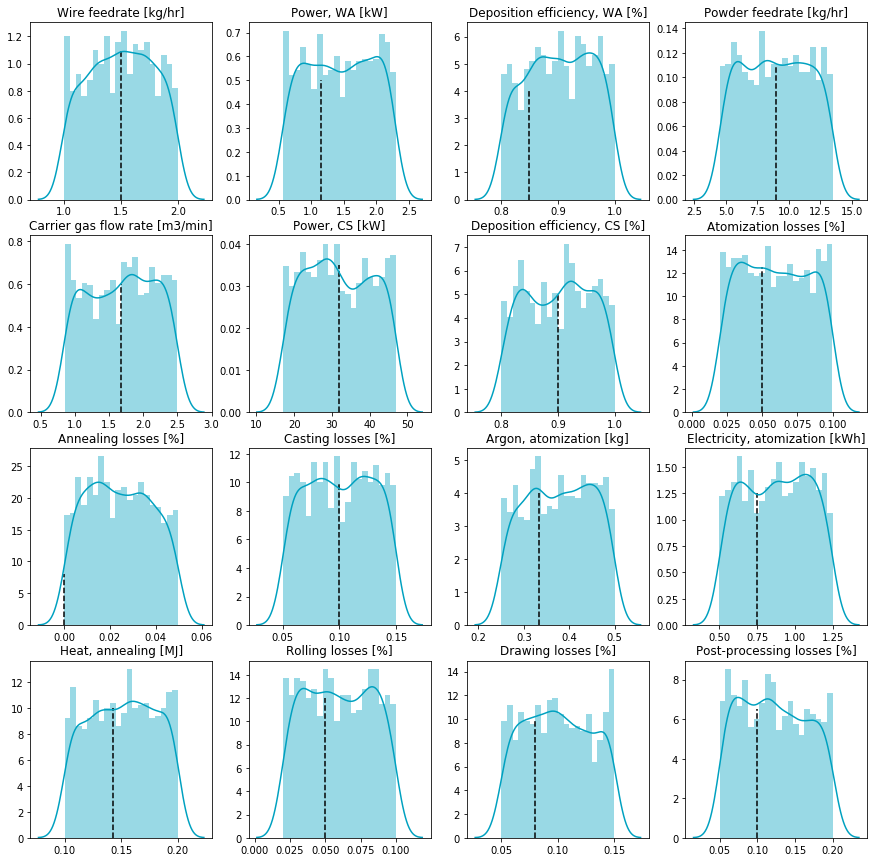

In [11]:
#Parameters
fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(15,15))
(sns.distplot(p_wire_fr, kde=True, bins=20, ax=axs[0,0], color=(0, 161/255, 192/255))).vlines(wire_fr, 0, 1.1, ls='--')
axs[0, 0].set_title('Wire feedrate [kg/hr]')
axs[0, 0].set_ylabel('')
(sns.distplot(p_power_wa, kde=True, bins=20, ax=axs[0,1], color=(0, 161/255, 192/255))).vlines(power_wa, 0, 0.5, ls='--')
axs[0, 1].set_title('Power, WA [kW]')
axs[0, 1].set_ylabel('')
(sns.distplot(p_dep_eff_wa, kde=True, bins=20, ax=axs[0,2], color=(0, 161/255, 192/255))).vlines(dep_eff_wa, 0, 4, ls='--')
axs[0, 2].set_title('Deposition efficiency, WA [%]')
axs[0, 2].set_ylabel('')
(sns.distplot(p_powder_fr, kde=True, bins=20, ax=axs[0,3], color=(0, 161/255, 192/255))).vlines(powder_fr, 0, 0.11, ls='--')
axs[0, 3].set_title('Powder feedrate [kg/hr]')
axs[0, 3].set_ylabel('')
(sns.distplot(p_car_gas_fr, kde=True, bins=20, ax=axs[1,0], color=(0, 161/255, 192/255))).vlines(car_gas_fr, 0, 0.6, ls='--')
axs[1, 0].set_title('Carrier gas flow rate [m3/min]')
axs[1, 0].set_ylabel('')
(sns.distplot(p_power_cs, kde=True, bins=20, ax=axs[1,1], color=(0, 161/255, 192/255))).vlines(power_cs, 0, 0.035, ls='--')
axs[1, 1].set_title('Power, CS [kW]')
axs[1, 1].set_ylabel('')
(sns.distplot(p_dep_eff_cs, kde=True, bins=20, ax=axs[1,2], color=(0, 161/255, 192/255))).vlines(dep_eff_cs, 0, 5, ls='--')
axs[1, 2].set_title('Deposition efficiency, CS [%]')
axs[1, 2].set_ylabel('')
(sns.distplot(p_atom_loss, kde=True, bins=20, ax=axs[1,3], color=(0, 161/255, 192/255))).vlines(atom_loss, 0, 12.5, ls='--')
axs[1, 3].set_title('Atomization losses [%]')
axs[1, 3].set_ylabel('')
(sns.distplot(p_anneal_loss, kde=True, bins=20, ax=axs[2,0], color=(0, 161/255, 192/255))).vlines(anneal_loss, 0, 8, ls='--')
axs[2, 0].set_title('Annealing losses [%]')
axs[2, 0].set_ylabel('')
(sns.distplot(p_cast_loss, kde=True, bins=20, ax=axs[2,1], color=(0, 161/255, 192/255))).vlines(cast_loss, 0, 10, ls='--')
axs[2, 1].set_title('Casting losses [%]')
axs[2, 1].set_ylabel('')
(sns.distplot(p_arg_atom, kde=True, bins=20, ax=axs[2,2], color=(0, 161/255, 192/255))).vlines(arg_atom, 0, 4, ls='--')
axs[2, 2].set_title('Argon, atomization [kg]')
axs[2, 2].set_ylabel('')
(sns.distplot(p_elec_atom, kde=True, bins=20, ax=axs[2,3], color=(0, 161/255, 192/255))).vlines(elec_atom, 0, 1.25, ls='--')
axs[2, 3].set_title('Electricity, atomization [kWh]')
axs[2, 3].set_ylabel('')
(sns.distplot(p_heat_anneal, kde=True, bins=20, ax=axs[3,0], color=(0, 161/255, 192/255))).vlines(heat_anneal, 0, 10, ls='--')
axs[3, 0].set_title('Heat, annealing [MJ]')
axs[3, 0].set_ylabel('')
(sns.distplot(p_roll_loss, kde=True, bins=20, ax=axs[3,1], color=(0, 161/255, 192/255))).vlines(roll_loss, 0, 12, ls='--')
axs[3, 1].set_title('Rolling losses [%]')
axs[3, 1].set_ylabel('')
(sns.distplot(p_draw_loss, kde=True, bins=20, ax=axs[3,2], color=(0, 161/255, 192/255))).vlines(draw_loss, 0, 10, ls='--')
axs[3, 2].set_title('Drawing losses [%]')
axs[3, 2].set_ylabel('')
(sns.distplot(p_post_proc_loss, kde=True, bins=20, ax=axs[3,3], color=(0, 161/255, 192/255))).vlines(post_proc_loss, 0, 6.5, ls='--')
axs[3, 3].set_title('Post-processing losses [%]')
axs[3, 3].set_ylabel('')
plt.savefig("Figure S2.jpg", format="jpg", dpi=400, bbox_inches='tight')
#plt.subplots_adjust(hspace=0.3)
#uncer_losses_per_kg.to_excel("output.xlsx", sheet_name="figure 2")
#plt.tight_layout()
#plt.savefig("Figure2.jpg", format="jpg", dpi=400, bbox_inches='tight')

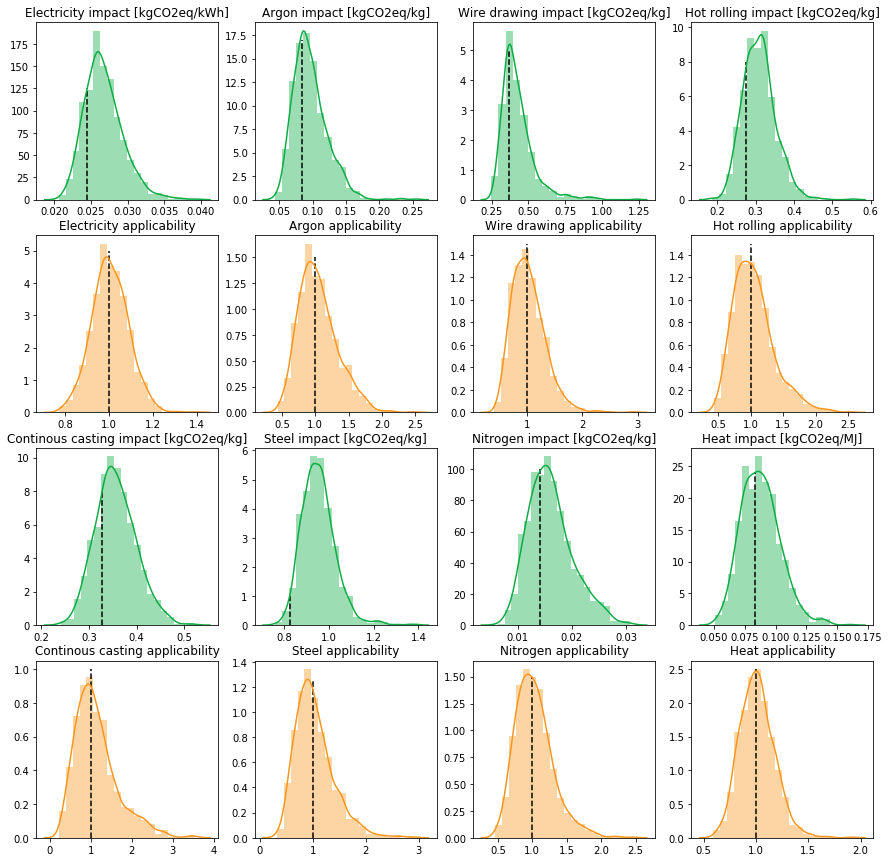

In [12]:
#background and applicability
fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(15,15))

(sns.distplot(t_impact_elec, kde=True, bins=20, ax=axs[0,0], color=(11/255, 172/255, 67/255))).vlines(impact_elec, 0, 125, ls='--')
axs[0, 0].set_title('Electricity impact [kgCO2eq/kWh]')
axs[0, 0].set_ylabel('')
(sns.distplot(a_elec, kde=True, bins=20, ax=axs[1,0], color=(250/255, 150/255, 30/255))).vlines(1, 0, 5, ls='--')
axs[1, 0].set_title('Electricity applicability')
axs[1, 0].set_ylabel('')
(sns.distplot(t_impact_arg, kde=True, bins=20, ax=axs[0,1], color=(11/255, 172/255, 67/255))).vlines(impact_arg, 0, 17, ls='--')
axs[0, 1].set_title('Argon impact [kgCO2eq/kg]')
axs[0, 1].set_ylabel('')
(sns.distplot(a_arg, kde=True, bins=20, ax=axs[1,1], color=(250/255, 150/255, 30/255))).vlines(1, 0, 1.5, ls='--')
axs[1, 1].set_title('Argon applicability')
axs[1, 1].set_ylabel('')
(sns.distplot(t_impact_draw, kde=True, bins=20, ax=axs[0,2], color=(11/255, 172/255, 67/255))).vlines(impact_draw, 0, 5, ls='--')
axs[0, 2].set_title('Wire drawing impact [kgCO2eq/kg]')
axs[0, 2].set_ylabel('')
(sns.distplot(a_draw, kde=True, bins=20, ax=axs[1,2], color=(250/255, 150/255, 30/255))).vlines(1, 0, 1.5, ls='--')
axs[1, 2].set_title('Wire drawing applicability')
axs[1, 2].set_ylabel('')
(sns.distplot(t_impact_roll, kde=True, bins=20, ax=axs[0,3], color=(11/255, 172/255, 67/255))).vlines(impact_roll, 0, 8, ls='--')
axs[0, 3].set_title('Hot rolling impact [kgCO2eq/kg]')
axs[0, 3].set_ylabel('')
(sns.distplot(a_roll, kde=True, bins=20, ax=axs[1,3], color=(250/255, 150/255, 30/255))).vlines(1, 0, 1.5, ls='--')
axs[1, 3].set_title('Hot rolling applicability')
axs[1, 3].set_ylabel('')
(sns.distplot(t_impact_cast, kde=True, bins=20, ax=axs[2,0], color=(11/255, 172/255, 67/255))).vlines(impact_cast, 0, 8, ls='--')
axs[2, 0].set_title('Continous casting impact [kgCO2eq/kg]')
axs[2, 0].set_ylabel('')
(sns.distplot(a_cast, kde=True, bins=20, ax=axs[3,0], color=(250/255, 150/255, 30/255))).vlines(1, 0, 1, ls='--')
axs[3, 0].set_title('Continous casting applicability')
axs[3, 0].set_ylabel('')
(sns.distplot(t_impact_steel, kde=True, bins=20, ax=axs[2,1], color=(11/255, 172/255, 67/255))).vlines(impact_steel, 0, 1, ls='--')
axs[2, 1].set_title('Steel impact [kgCO2eq/kg]')
axs[2, 1].set_ylabel('')
(sns.distplot(a_steel, kde=True, bins=20, ax=axs[3,1], color=(250/255, 150/255, 30/255))).vlines(1, 0, 1.25, ls='--')
axs[3, 1].set_title('Steel applicability')
axs[3, 1].set_ylabel('')
(sns.distplot(t_impact_nit, kde=True, bins=20, ax=axs[2,2], color=(11/255, 172/255, 67/255))).vlines(impact_nit, 0, 100, ls='--')
axs[2, 2].set_title('Nitrogen impact [kgCO2eq/kg]')
axs[2, 2].set_ylabel('')
(sns.distplot(a_nit, kde=True, bins=20, ax=axs[3,2], color=(250/255, 150/255, 30/255))).vlines(1, 0, 1.5, ls='--')
axs[3, 2].set_title('Nitrogen applicability')
axs[3, 2].set_ylabel('')
(sns.distplot(t_impact_heat, kde=True, bins=20, ax=axs[2,3], color=(11/255, 172/255, 67/255))).vlines(impact_heat, 0, 24, ls='--')
axs[2, 3].set_title('Heat impact [kgCO2eq/MJ]')
axs[2, 3].set_ylabel('')
(sns.distplot(a_heat, kde=True, bins=20, ax=axs[3,3], color=(250/255, 150/255, 30/255))).vlines(1, 0, 2.5, ls='--')
axs[3, 3].set_title('Heat applicability')
axs[3, 3].set_ylabel('')
plt.savefig("Figure S3.jpg", format="jpg", dpi=400, bbox_inches='tight')

In [13]:
#impact calculation
#deterministic
impact_atom = (elec_atom * impact_elec) + (arg_atom * impact_arg)
impact_anneal = (heat_anneal * impact_heat)
impact_mat_cs = (coating_amount * impact_anneal) + (coating_amount * impact_atom) + (powder * impact_steel)
impact_elec_cs = elec_cs * impact_elec
impact_gas_cs = nit_cs * impact_nit
impact_cs = impact_mat_cs + impact_elec_cs + impact_gas_cs
impact_mat_wa =  (coating_amount * impact_draw) + (coating_amount * impact_roll) + (coating_amount * impact_cast) + (wire * impact_steel)
impact_elec_wa = elec_wa * impact_elec
impact_gas_wa = arg_wa * impact_arg
impact_wa  = impact_mat_wa + impact_gas_wa + impact_elec_wa
impact_difference = impact_wa - impact_cs

#probabilistic
bins = 20
t_impact_atom = (p_elec_atom * t_impact_elec * a_elec) + (p_arg_atom * t_impact_arg * a_arg)
t_impact_anneal = (p_heat_anneal * t_impact_heat * a_heat)
t_impact_wire =  (coating_amount * t_impact_draw * a_draw) + (coating_amount * t_impact_roll * a_roll) + (coating_amount * t_impact_cast * a_cast) + (p_wire * t_impact_steel * a_steel)
t_impact_powder = (coating_amount * t_impact_anneal) + (coating_amount * t_impact_atom) + (p_powder * t_impact_steel * a_steel)
MC_impact_cs = t_impact_powder + (p_elec_cs * t_impact_elec * a_elec) + (p_nit_cs * t_impact_nit * a_nit)
MC_impact_wa  = t_impact_wire + (p_elec_wa * t_impact_elec * a_elec) + (p_arg_wa * t_impact_arg * a_arg) 
MC_impact_difference = MC_impact_wa - MC_impact_cs

#Global Sensitivity Analysis
GSA_results = {}
for i in range(len(parameters)):
    GSA_results.update({parameters_names[i]:SI_1st(parameters[i],MC_impact_difference,iterations,bins)})

# Results

In [14]:
impact_difference

0.7312614623879838

In [15]:
impact_cs

1.709985560466131

In [16]:
impact_wa

2.4412470228541148

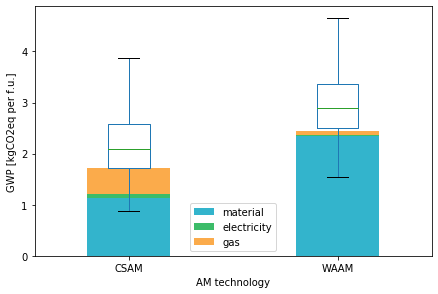

In [17]:
# Calculate mean and standard deviation for CSAM and WAAM
mean_cs = np.mean(MC_impact_cs)
mean_wa = np.mean(MC_impact_wa)

std_cs = np.std(MC_impact_cs)
std_wa = np.std(MC_impact_wa)

# Create DataFrame for boxplot
boxplot_data = pd.DataFrame({'CSAM': MC_impact_cs, 'WAAM': MC_impact_wa})

# Plotting
fig, ax = plt.subplots()

# Plot bar graph for CSAM and WAAM
contribution = pd.DataFrame({'material': [impact_mat_cs, impact_mat_wa],
                             'electricity': [impact_elec_cs, impact_elec_wa],
                             'gas': [impact_gas_cs, impact_gas_wa]},
                            index=['CSAM', 'WAAM'])
contribution.plot(kind='bar', stacked=True, ax=ax,
                  color=[(0, 161/255, 192/255, 0.8), 
                         (11/255, 172/255, 67/255, 0.8), 
                         (250/255, 150/255, 30/255, 0.8)],
                  width=0.4, position=0.5)  # Adjust the position and width

# Overlay hollow boxplot without outliers
positions = [0, 1]  # Adjust the positions to match the bars
boxplot_data.boxplot(ax=ax, positions=positions, widths=0.2, patch_artist=False, showfliers=False, showmeans=False)

ax.set_xticks(positions)
ax.set_xticklabels(['CSAM', 'WAAM'])

# Remove grid lines
ax.grid(False)

# Add legend for bar plot (original)
plt.legend(loc='best')
plt.tight_layout()

plt.ylabel('GWP [kgCO2eq per f.u.]')
plt.xlabel('AM technology')

plt.savefig("Figure S5.jpg", format="jpg", dpi=400, bbox_inches='tight')
plt.show()

In [18]:
print(impact_mat_wa/impact_wa)

0.9583566156159102


In [19]:
print(impact_elec_wa/impact_wa)

0.007643590837851638


In [20]:
print(impact_gas_wa/impact_wa)

0.03399979354623794


In [21]:
print(impact_mat_cs/impact_cs)

0.660971181909891


In [22]:
print(impact_elec_cs/impact_cs)

0.05075788357203489


In [23]:
print(impact_gas_cs/impact_cs)

0.288270934518074


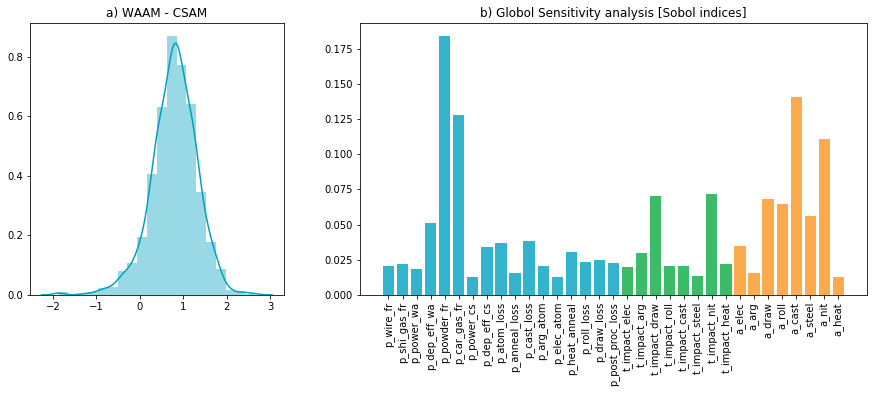

In [24]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15,5), gridspec_kw={'width_ratios': [5, 10]})
sns.distplot(MC_impact_difference, kde=True, bins=20, ax=axs[0], color=(0, 161/255, 192/255))
axs[0].set_title('a) WAAM - CSAM')
axs[0].set_ylabel('')
colors = [(0, 161/255, 192/255, 0.8)] * 17 + [(11/255, 172/255, 67/255, 0.8)] * 8 + [(250/255, 150/255, 30/255, 0.8)] * 8
axs[1].bar(range(len(GSA_results)), list(GSA_results.values()), align='center', color=colors)
axs[1].set_xticks(range(len(GSA_results)))
axs[1].set_title('b) Globol Sensitivity analysis [Sobol indices]')
axs[1].set_xticklabels(list(GSA_results.keys()), rotation=90)
plt.savefig("Figure 3.jpg", format="jpg", dpi=400, bbox_inches='tight')
#ax2 = axs[1].twinx()
#ax2.plot(range(len(GSA_results)), times, 'kx', markersize=5, label='adjusted to time')
#efficient_times = [(a / b) * 10000 for a, b in zip(list(GSA_results.values()),times)]
#ax2.plot(range(len(GSA_results)), efficient_times, 'kx', markersize=5, label='adjusted to time')

In [25]:
pos_count, neg_count = 0, 0
for num in MC_impact_difference:
    if num >= 0:
        pos_count += 1
    else:
        neg_count += 1         
print("WA > CS:", (pos_count/len(MC_impact_difference))*100,"%")
print("WA < CS:", (neg_count/len(MC_impact_difference))*100,"%")

WA > CS: 93.60000000000001 %
WA < CS: 6.4 %


## Second iteration

In [26]:
#Fix the value of powder_fr and p_powder_fr
powder_fr = 1.5
p_powder_fr = np.random.uniform (1.2,1.8,iterations)

#formulas based on powder_fr and p_powder_fr
duration_cs = 1/powder_fr
p_duration_cs = 1/p_powder_fr
elec_cs = power_cs*duration_cs
p_elec_cs = p_power_cs*p_duration_cs
nit_cs =  car_gas_fr*duration_cs*density_n*60 
p_nit_cs =  p_car_gas_fr*p_duration_cs*density_n*60

#Redo deterministic calculations
impact_atom = (elec_atom * impact_elec) + (arg_atom * impact_arg)
impact_anneal = (heat_anneal * impact_heat)
impact_mat_cs = (coating_amount * impact_anneal) + (coating_amount * impact_atom) + (powder * impact_steel)
impact_elec_cs = elec_cs * impact_elec
impact_gas_cs = nit_cs * impact_nit
impact_cs = impact_mat_cs + impact_elec_cs + impact_gas_cs
impact_mat_wa =  (coating_amount * impact_draw) + (coating_amount * impact_roll) + (coating_amount * impact_cast) + (wire * impact_steel)
impact_elec_wa = elec_wa * impact_elec
impact_gas_wa = arg_wa * impact_arg
impact_wa  = impact_mat_wa + impact_gas_wa + impact_elec_wa
impact_difference = impact_wa - impact_cs

#Redo probabilistic calculation (Monte Carlo)
t_impact_atom = (p_elec_atom * t_impact_elec * a_elec) + (p_arg_atom * t_impact_arg * a_arg)
t_impact_anneal = (p_heat_anneal * t_impact_heat * a_heat)
t_impact_wire =  (coating_amount * t_impact_draw * a_draw) + (coating_amount * t_impact_roll * a_roll) + (coating_amount * t_impact_cast * a_cast) + (p_wire * t_impact_steel * a_steel)
t_impact_powder = (coating_amount * t_impact_anneal) + (coating_amount * t_impact_atom) + (p_powder * t_impact_steel * a_steel)
MC_impact_cs = t_impact_powder + (p_elec_cs * t_impact_elec * a_elec) + (p_nit_cs * t_impact_nit * a_nit)
MC_impact_wa  = t_impact_wire + (p_elec_wa * t_impact_elec * a_elec) + (p_arg_wa * t_impact_arg * a_arg) 
MC_impact_difference = MC_impact_wa - MC_impact_cs

#Global Sensitivity Analysis
GSA_results = {}
for i in range(len(parameters)):
    GSA_results.update({parameters_names[i]:SI_1st(parameters[i],MC_impact_difference,iterations,bins)})

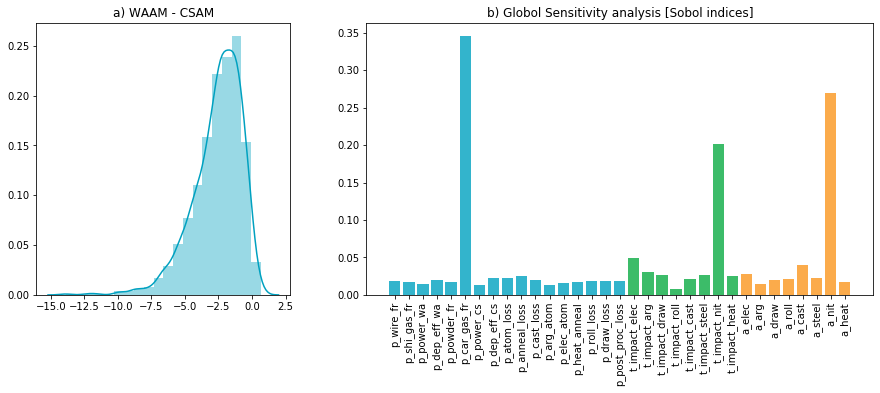

In [27]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15,5), gridspec_kw={'width_ratios': [5, 10]})
sns.distplot(MC_impact_difference, kde=True, bins=20, ax=axs[0], color=(0, 161/255, 192/255))
axs[0].set_title('a) WAAM - CSAM')
axs[0].set_ylabel('')
colors = [(0, 161/255, 192/255, 0.8)] * 17 + [(11/255, 172/255, 67/255, 0.8)] * 8 + [(250/255, 150/255, 30/255, 0.8)] * 8
axs[1].bar(range(len(GSA_results)), list(GSA_results.values()), align='center', color=colors)
axs[1].set_xticks(range(len(GSA_results)))
axs[1].set_title('b) Globol Sensitivity analysis [Sobol indices]')
axs[1].set_xticklabels(list(GSA_results.keys()), rotation=90)
plt.savefig("Figure 4.jpg", format="jpg", dpi=400, bbox_inches='tight')
#ax2 = axs[1].twinx()
#efficient_times = [(a / b) * 10000 for a, b in zip(list(GSA_results.values()),times)]
#ax2.plot(range(len(GSA_results)), efficient_times, 'kx', markersize=5, label='adjusted to time')

In [28]:
pos_count, neg_count = 0, 0
for num in MC_impact_difference:
    if num >= 0:
        pos_count += 1
    else:
        neg_count += 1         
print("WA > CS:", (pos_count/len(MC_impact_difference))*100,"%")
print("WA < CS:", (neg_count/len(MC_impact_difference))*100,"%")

WA > CS: 1.9 %
WA < CS: 98.1 %


# Third Iteration

In [29]:
#Fix the value of car_gas_fr and p_car_gas_fr
car_gas_fr = 0.175
p_car_gas_fr = np.random.uniform (0.15,0.2,iterations)

#formulas based on car_fr and p_car_fr
nit_cs =  car_gas_fr*duration_cs*density_n*60 
p_nit_cs =  p_car_gas_fr*p_duration_cs*density_n*60

#Redo deterministic calculations
impact_atom = (elec_atom * impact_elec) + (arg_atom * impact_arg)
impact_anneal = (heat_anneal * impact_heat)
impact_mat_cs = (coating_amount * impact_anneal) + (coating_amount * impact_atom) + (powder * impact_steel)
impact_elec_cs = elec_cs * impact_elec
impact_gas_cs = nit_cs * impact_nit
impact_cs = impact_mat_cs + impact_elec_cs + impact_gas_cs
impact_mat_wa =  (coating_amount * impact_draw) + (coating_amount * impact_roll) + (coating_amount * impact_cast) + (wire * impact_steel)
impact_elec_wa = elec_wa * impact_elec
impact_gas_wa = arg_wa * impact_arg
impact_wa  = impact_mat_wa + impact_gas_wa + impact_elec_wa
impact_difference = impact_wa - impact_cs

#Redo probabilistic calculation (Monte Carlo)
t_impact_atom = (p_elec_atom * t_impact_elec * a_elec) + (p_arg_atom * t_impact_arg * a_arg)
t_impact_anneal = (p_heat_anneal * t_impact_heat * a_heat)
t_impact_wire =  (coating_amount * t_impact_draw * a_draw) + (coating_amount * t_impact_roll * a_roll) + (coating_amount * t_impact_cast * a_cast) + (p_wire * t_impact_steel * a_steel)
t_impact_powder = (coating_amount * t_impact_anneal) + (coating_amount * t_impact_atom) + (p_powder * t_impact_steel * a_steel)
MC_impact_cs = t_impact_powder + (p_elec_cs * t_impact_elec * a_elec) + (p_nit_cs * t_impact_nit * a_nit)
MC_impact_wa  = t_impact_wire + (p_elec_wa * t_impact_elec * a_elec) + (p_arg_wa * t_impact_arg * a_arg) 
MC_impact_difference = MC_impact_wa - MC_impact_cs

#Global Sensitivity Analysis
GSA_results = {}
for i in range(len(parameters)):
    GSA_results.update({parameters_names[i]:SI_1st(parameters[i],MC_impact_difference,iterations,bins)})

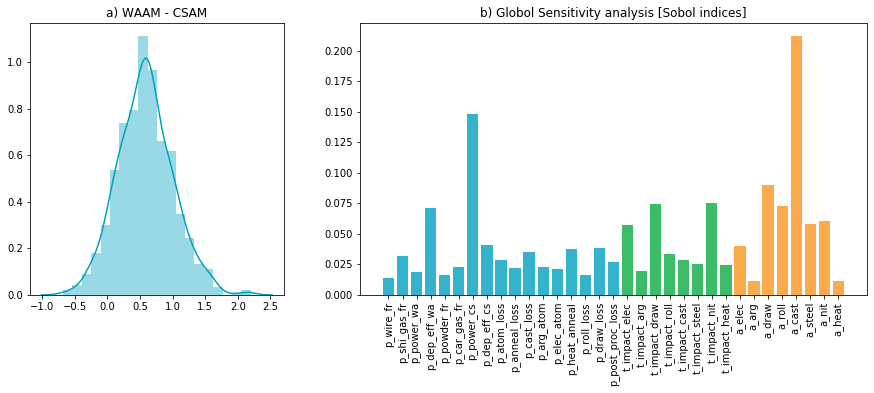

In [30]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15,5), gridspec_kw={'width_ratios': [5, 10]})
sns.distplot(MC_impact_difference, kde=True, bins=20, ax=axs[0], color=(0, 161/255, 192/255))
axs[0].set_title('a) WAAM - CSAM')
axs[0].set_ylabel('')
colors = [(0, 161/255, 192/255, 0.8)] * 17 + [(11/255, 172/255, 67/255, 0.8)] * 8 + [(250/255, 150/255, 30/255, 0.8)] * 8
axs[1].bar(range(len(GSA_results)), list(GSA_results.values()), align='center', color=colors)
axs[1].set_xticks(range(len(GSA_results)))
axs[1].set_title('b) Globol Sensitivity analysis [Sobol indices]')
axs[1].set_xticklabels(list(GSA_results.keys()), rotation=90)
plt.savefig("Figure 5.jpg", format="jpg", dpi=400, bbox_inches='tight')
#ax2 = axs[1].twinx()
#efficient_times = [(a / b) * 10000 for a, b in zip(list(GSA_results.values()),times)]
#ax2.plot(range(len(GSA_results)), efficient_times, 'kx', markersize=5, label='adjusted to time')

In [31]:
pos_count, neg_count = 0, 0
for num in MC_impact_difference:
    if num >= 0:
        pos_count += 1
    else:
        neg_count += 1         
print("WA > CS:", (pos_count/len(MC_impact_difference))*100,"%")
print("WA < CS:", (neg_count/len(MC_impact_difference))*100,"%")

WA > CS: 92.4 %
WA < CS: 7.6 %


# Fourth iteration

In [32]:
#Fix the value of power_cs and p_power_cs
power_cs = 80.35
p_power_cs = np.random.uniform (43.05,106.85,iterations)

#formulas based on power_cs and p_power_cs
elec_cs = power_cs*duration_cs
p_elec_cs = p_power_cs*p_duration_cs

#Redo deterministic calculations
impact_atom = (elec_atom * impact_elec) + (arg_atom * impact_arg)
impact_anneal = (heat_anneal * impact_heat)
impact_mat_cs = (coating_amount * impact_anneal) + (coating_amount * impact_atom) + (powder * impact_steel)
impact_elec_cs = elec_cs * impact_elec
impact_gas_cs = nit_cs * impact_nit
impact_cs = impact_mat_cs + impact_elec_cs + impact_gas_cs
impact_mat_wa =  (coating_amount * impact_draw) + (coating_amount * impact_roll) + (coating_amount * impact_cast) + (wire * impact_steel)
impact_elec_wa = elec_wa * impact_elec
impact_gas_wa = arg_wa * impact_arg
impact_wa  = impact_mat_wa + impact_gas_wa + impact_elec_wa
impact_difference = impact_wa - impact_cs

#Redo probabilistic calculation (Monte Carlo)
t_impact_atom = (p_elec_atom * t_impact_elec * a_elec) + (p_arg_atom * t_impact_arg * a_arg)
t_impact_anneal = (p_heat_anneal * t_impact_heat * a_heat)
t_impact_wire =  (coating_amount * t_impact_draw * a_draw) + (coating_amount * t_impact_roll * a_roll) + (coating_amount * t_impact_cast * a_cast) + (p_wire * t_impact_steel * a_steel)
t_impact_powder = (coating_amount * t_impact_anneal) + (coating_amount * t_impact_atom) + (p_powder * t_impact_steel * a_steel)
MC_impact_cs = t_impact_powder + (p_elec_cs * t_impact_elec * a_elec) + (p_nit_cs * t_impact_nit * a_nit)
MC_impact_wa  = t_impact_wire + (p_elec_wa * t_impact_elec * a_elec) + (p_arg_wa * t_impact_arg * a_arg) 
MC_impact_difference = MC_impact_wa - MC_impact_cs

#Global Sensitivity Analysis
GSA_results = {}
for i in range(len(parameters)):
    GSA_results.update({parameters_names[i]:SI_1st(parameters[i],MC_impact_difference,iterations,bins)})

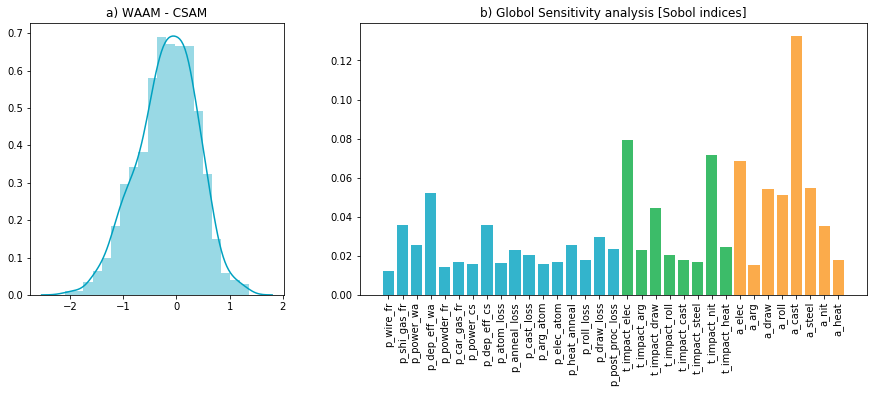

In [33]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15,5), gridspec_kw={'width_ratios': [5, 10]})
sns.distplot(MC_impact_difference, kde=True, bins=20, ax=axs[0], color=(0, 161/255, 192/255))
axs[0].set_title('a) WAAM - CSAM')
axs[0].set_ylabel('')
colors = [(0, 161/255, 192/255, 0.8)] * 17 + [(11/255, 172/255, 67/255, 0.8)] * 8 + [(250/255, 150/255, 30/255, 0.8)] * 8
axs[1].bar(range(len(GSA_results)), list(GSA_results.values()), align='center', color=colors)
axs[1].set_xticks(range(len(GSA_results)))
axs[1].set_title('b) Globol Sensitivity analysis [Sobol indices]')
axs[1].set_xticklabels(list(GSA_results.keys()), rotation=90)
plt.savefig("Figure 6.jpg", format="jpg", dpi=400, bbox_inches='tight')
#ax2 = axs[1].twinx()
#efficient_times = [(a / b) * 10000 for a, b in zip(list(GSA_results.values()),times)]
#ax2.plot(range(len(GSA_results)), efficient_times, 'kx', markersize=5, label='adjusted to time')

In [34]:
pos_count, neg_count = 0, 0
for num in MC_impact_difference:
    if num >= 0:
        pos_count += 1
    else:
        neg_count += 1         
print("WA > CS:", (pos_count/len(MC_impact_difference))*100,"%")
print("WA < CS:", (neg_count/len(MC_impact_difference))*100,"%")

WA > CS: 40.6 %
WA < CS: 59.4 %


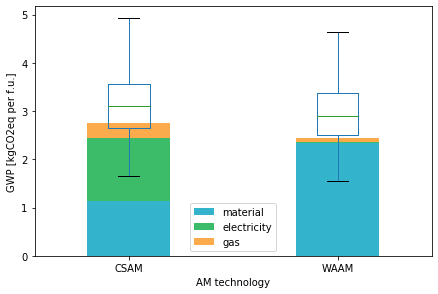

In [35]:
# Calculate mean and standard deviation for CSAM and WAAM
mean_cs = np.mean(MC_impact_cs)
mean_wa = np.mean(MC_impact_wa)

std_cs = np.std(MC_impact_cs)
std_wa = np.std(MC_impact_wa)

# Create DataFrame for boxplot
boxplot_data = pd.DataFrame({'CSAM': MC_impact_cs, 'WAAM': MC_impact_wa})

# Plotting
fig, ax = plt.subplots()

# Plot bar graph for CSAM and WAAM
contribution = pd.DataFrame({'material': [impact_mat_cs, impact_mat_wa],
                             'electricity': [impact_elec_cs, impact_elec_wa],
                             'gas': [impact_gas_cs, impact_gas_wa]},
                            index=['CSAM', 'WAAM'])
contribution.plot(kind='bar', stacked=True, ax=ax,
                  color=[(0, 161/255, 192/255, 0.8), 
                         (11/255, 172/255, 67/255, 0.8), 
                         (250/255, 150/255, 30/255, 0.8)],
                  width=0.4, position=0.5)  # Adjust the position and width

# Overlay hollow boxplot without outliers
positions = [0, 1]  # Adjust the positions to match the bars
boxplot_data.boxplot(ax=ax, positions=positions, widths=0.2, patch_artist=False, showfliers=False, showmeans=False)

ax.set_xticks(positions)
ax.set_xticklabels(['CSAM', 'WAAM'])

# Remove grid lines
ax.grid(False)

# Add legend for bar plot (original)
plt.legend(loc='best')
plt.tight_layout()

plt.ylabel('GWP [kgCO2eq per f.u.]')
plt.xlabel('AM technology')

plt.savefig("Figure S6.jpg", format="jpg", dpi=400, bbox_inches='tight')
plt.show()

In [36]:
#FIX df names, might need to do it in order
#with pd.ExcelWriter('output.xlsx') as writer:
#    uncer_losses_per_kg.to_excel(writer, sheet_name='figure 2')
#    concatenated_mfa.to_excel(writer, sheet_name='figure 3')
#    concatenated_df.to_excel(writer, sheet_name='figure 4')
#    dynamic.to_excel(writer, sheet_name='figure s2')
#    results_df_temp.to_excel(writer, sheet_name='figure S3')
#    results_df_temp_t_stacked.to_excel(writer, sheet_name='figure S4')

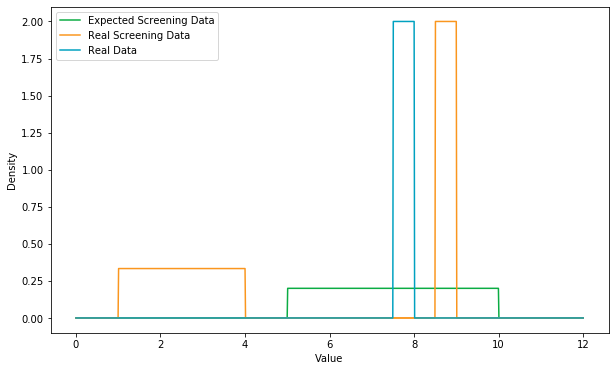

In [37]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Define the ranges for the uniform distributions
ranges = [
    (5, 10),     # Expected screening data
    (1, 4),      # Real screening data 1
    (8.5, 9),    # Real screening data 2
    (7.5, 8)     # Real data
]

# Define colors
expected_screening_color = (11/255, 172/255, 67/255)
real_screening_color = (250/255, 150/255, 30/255)
real_data_color = (0, 161/255, 192/255)

# Create a figure and axis
plt.figure(figsize=(10, 6))

# Plot the KDEs using uniform distributions
x_values = np.linspace(0, 12, 1000)

for (start, end), color, label in zip(ranges, [expected_screening_color, real_screening_color, real_screening_color, real_data_color],
                                      ['Expected Screening Data', 'Real Screening Data', None, 'Real Data']):
    y_values = uniform.pdf(x_values, loc=start, scale=end - start)
    plt.plot(x_values, y_values, color=color, label=label)

# Add legend
plt.legend()

# Add titles and labels
plt.xlabel("Value")
plt.ylabel("Density")

# Show plot
plt.savefig("Figure 7.jpg", format="jpg", dpi=400, bbox_inches='tight')
plt.show()


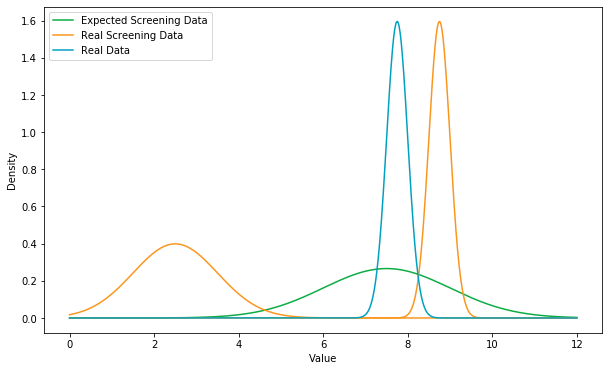

In [38]:
#Not used, normal instead of uniform distribution

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the means and standard deviations for the distributions
means = [7.5, 2.5, 8.75, 7.75]
std_devs = [1.5, 1, 0.25, 0.25]

# Define colors
expected_screening_color = (11/255, 172/255, 67/255)
real_screening_color = (250/255, 150/255, 30/255)
real_data_color = (0, 161/255, 192/255)

# Define x values for plotting the PDFs
x_values = np.linspace(0, 12, 1000)

# Create a figure and axis
plt.figure(figsize=(10, 6))

# Plot the KDEs using the PDFs of normal distributions
plt.plot(x_values, norm.pdf(x_values, loc=means[0], scale=std_devs[0]), color=expected_screening_color, label='Expected Screening Data')
plt.plot(x_values, norm.pdf(x_values, loc=means[1], scale=std_devs[1]), color=real_screening_color, label='Real Screening Data')
plt.plot(x_values, norm.pdf(x_values, loc=means[2], scale=std_devs[2]), color=real_screening_color)  # Same color, no additional label
plt.plot(x_values, norm.pdf(x_values, loc=means[3], scale=std_devs[3]), color=real_data_color, label='Real Data')

# Add legend
plt.legend()

# Add titles and labels
plt.xlabel("Value")
plt.ylabel("Density")

# Show plot
plt.show()

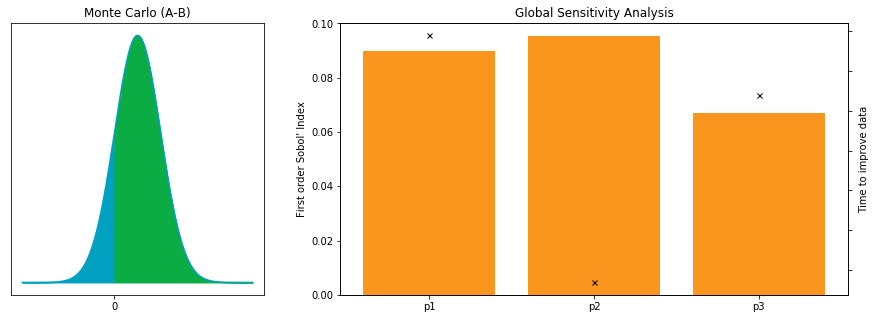

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Sample data
x = np.linspace(-4, 6, 1000)
color1 = (0, 161/255, 192/255)
color2 = (11/255, 172/255, 67/255)
color3 = (250/255, 150/255, 30/255)

# Create subplots
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 5), gridspec_kw={'width_ratios': [5, 10]})

# Plot normal distribution with shaded regions
axs[0].plot(x, norm.pdf(x, loc=1), color=color1)
axs[0].fill_between(x[x <= 0], norm.pdf(x[x <= 0], loc=1), color=color1)
axs[0].fill_between(x[x > 0], norm.pdf(x[x > 0], loc=1), color=color2)
axs[0].set_xticks([0])
axs[0].set_xticklabels(['0'])
axs[0].set_yticks([])

# Set title
axs[0].set_title('Monte Carlo (A-B)')

# For the second plot, we'll use random values for p1, p2, and p3 less than 0.1
p_values = np.random.uniform(0, 0.1, size=3)
threshold = 0.1
time_values = np.random.rand(3)  # Random time values

# Create secondary axis with time
ax2 = axs[1].twinx()

# Plot bar chart for p1, p2, p3
axs[1].bar(['p1', 'p2', 'p3'], p_values, color=color3)

# Plot dashed horizontal line at threshold
axs[1].axhline(y=threshold, color='gray', linestyle='--')

# Set secondary axis for time
ax2.plot(['p1', 'p2', 'p3'], time_values, 'kx', markersize=5, label='Time')
ax2.set_yticklabels([])

# Set title and labels
axs[1].set_title('Global Sensitivity Analysis')
axs[1].set_ylabel('First order Sobol\' Index')
ax2.set_ylabel('Time to improve data')

# Show plot
plt.savefig("Figure 8.jpg", format="jpg", dpi=400, bbox_inches='tight')
plt.show()


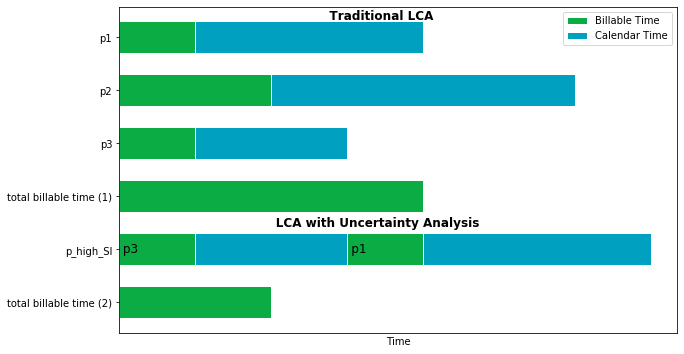

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
categories = ['p1', 'p2', 'p3', 'total billable time (1)', 'p_high_SI', 'total billable time (2)']
billable_time = [1, 2, 1, 1+2+1, 1, 1+1, 1]  # Sum of billable times for the total categories
calendar_time = [3, 4, 2, 0, 2, 3, 0]  # Sum of calendar times for the total categories

# Colors
billable_time_color = (11/255, 172/255, 67/255)
calendar_time_color = (0, 161/255, 192/255)

# Create horizontal stacked bar graph
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars for billable time for the first set
ax.barh(categories[:5], billable_time[:5], color=billable_time_color, edgecolor='white', height=0.6, label='Billable Time')
ax.barh(categories[4], billable_time[6], color=billable_time_color, edgecolor='white', height=0.6)

# Plot the bars for billable time for the second set
ax.barh(categories[5], billable_time[5], color=billable_time_color, edgecolor='white', height=0.6)

# Plot the bars for calendar time
ax.barh(categories[:4], calendar_time[:4], left=billable_time[:4], color=calendar_time_color, edgecolor='white', height=0.6, label='Calendar Time')

# Calculate the left positions for the second set of bars in "p_high_SI"
left_positions_p_high_SI = [billable_time[4], billable_time[4] + calendar_time[4] + billable_time[5]]

# Plot the bars for calendar time in "p_high_SI"
ax.barh(categories[4], calendar_time[4], left=left_positions_p_high_SI[0], color=calendar_time_color, edgecolor='white', height=0.6)
ax.barh(categories[4], calendar_time[5], left=left_positions_p_high_SI[1]-1, color=calendar_time_color, edgecolor='white', height=0.6)

# Fill empty space with green color
ax.barh(categories[4], billable_time[4], left=left_positions_p_high_SI[0] + calendar_time[4], color=billable_time_color, edgecolor='white', height=0.6)

# Add legend
ax.legend()

# Add separators and text to indicate groups
#plt.axhline(y=3.5, color='black', linewidth=0.8, linestyle='--')  # Separator line between groups
plt.text(0, -0.4, '                                                   Traditional LCA', fontsize=12, verticalalignment='center', fontweight='bold')
plt.text(0, 3.5, '                                      LCA with Uncertainty Analysis', fontsize=12, verticalalignment='center', fontweight='bold')
plt.text(0, 4, ' p3                                                       p1', fontsize=12, verticalalignment='center')

# Add vertical lines
#ax.axvline(x=6, color='black', linestyle='--')  # Vertical line at x = 6
#ax.axvline(x=7, color='black', linestyle='--') # Vertical line at x = 7

# Adjust y-axis to reverse the order of categories
ax.invert_yaxis()

# Remove x-axis numbers
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Add x-axis title
ax.set_xlabel('Time')

# Show plot
plt.savefig("Figure 9.jpg", format="jpg", dpi=400, bbox_inches='tight')
plt.show()
